# Data Processing & Analysis

## Overview
This notebook presents the data preprocessing pipeline for the LegalCon dataset, including cleaning, normalization, validation, and stratified splitting. The goal is to construct a high-quality dataset for three tasks: manipulation detection, manipulator identification, and technique classification.


## 1. Setup & Imports

In [30]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
import sys
import re
import numpy as np

## 2. Dataset Overview

### 2.1 Load and Examine Dataset

In [31]:
df = pd.read_csv("/kaggle/input/legalcon-dataset/LegalCon-Dataset.csv")
df.info()
df.head(10)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1038 entries, 0 to 1037
Data columns (total 5 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   IDs                      1038 non-null   int64 
 1   Dialogue                 1038 non-null   object
 2   Manipulative             1038 non-null   int64 
 3   Primary Manipulator      635 non-null    object
 4   Manipulation Techniques  636 non-null    object
dtypes: int64(2), object(3)
memory usage: 40.7+ KB


,IDs,Dialogue,Manipulative,Primary Manipulator,Manipulation Techniques
0,804,**[Judge]**\nWelcome back to The People's Cour...,1,plaintiff,"gaslighting, deflection"
1,154,Judge: you shouldn't have a problem paying the...,1,defendant,"Minimization, Deflection"
2,566,Judge: But it says a notice to appear under Se...,0,NaN,NaN
3,594,"Judge: All parties, please raise your right ha...",1,defendant,"minimization,Deflection, dismissal"
4,116,"Judge:\nOkay, Elias Samas.\n\nPlaintiff:\nThat...",1,defendant,minimization deflection persuasion
5,780,Judge\n-- but I just want to understand what's...,0,NaN,NaN
6,558,"Judge: All parties, please welcome back to the...",1,plaintiff,"deflection, minimization, persuasion"
7,762,"Judge: ""But you had told him, 'I'm pregnant ei...",1,defendant,"Minimization, deflection"
8,656,"Judge: Tracy Unique Alexander. Yes, you are su...",1,defendant,"character attack, playing the victim, gaslight..."
9,956,Judge: So all of this money and he hasn't give...,1,defendant,"Minimization, Evasion"


In [32]:
df.nunique()

IDs                        1038
Dialogue                   1035
Manipulative                  2
Primary Manipulator          11
Manipulation Techniques     485
dtype: int64

### Identify Missing Values and Data Quality Issues

In [33]:
print("Missing values in each column:")
print(df.isnull().sum())
print("\nMissing values percentage:")
print((df.isnull().sum() / len(df) * 100).round(2))
print(f"\nTotal rows with any missing values: {df.isnull().any(axis=1).sum()}")

Missing values in each column:
IDs                          0
Dialogue                     0
Manipulative                 0
Primary Manipulator        403
Manipulation Techniques    402
dtype: int64

Missing values percentage:
IDs                         0.00
Dialogue                    0.00
Manipulative                0.00
Primary Manipulator        38.82
Manipulation Techniques    38.73
dtype: float64

Total rows with any missing values: 403


Manipulative distribution:
              Count  Percent (%)
Manipulative                    
1               636        61.27
0               402        38.73


Text(0, 0.5, 'Count')

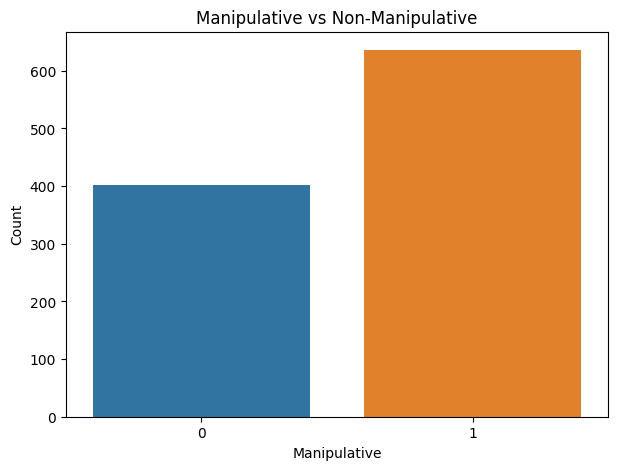

In [34]:
counts = df['Manipulative'].value_counts()
percent = (counts / counts.sum() * 100).round(2)

print("Manipulative distribution:")
print(pd.DataFrame({"Count": counts, "Percent (%)": percent}))

plt.figure(figsize=(7, 5))
sns.barplot(x=counts.index, y=counts.values)
plt.title('Manipulative vs Non-Manipulative')
plt.ylabel('Count')

## 3. Data Cleaning

Removed duplicate dialogues 

In [35]:
dup_mask = df["Dialogue"].duplicated(keep=False)
dup_dialogues = df[dup_mask].sort_values("Dialogue")

print(f"Duplicate rows: {dup_mask.sum()}")
print(f"Duplicate dialogue values: {dup_dialogues['Dialogue'].nunique()}")

Duplicate rows: 6
Duplicate dialogue values: 3


In [36]:
dup_count = df['Dialogue'].duplicated().sum()
df = df.drop_duplicates(subset=['Dialogue'], keep='first')

print(f"Removed {dup_count} duplicates → {len(df)} rows remaining")
print(f"Missing Dialogue: {df['Dialogue'].isna().sum()}")

Removed 3 duplicates → 1035 rows remaining
Missing Dialogue: 0


## 4. Label Normalization

### 4.1 Primary Manipulator Normalization

In [37]:
col = df['Primary Manipulator']

print(f"Total rows: {len(df)}")
print(f"Unique values: {col.nunique()}")
print("\nValues:")
print(col.unique())

Total rows: 1035
Unique values: 11

Values:
['plaintiff' 'defendant' nan 'Defendant' 'defendent' 'Plaintiff'
 'plaintiff ' 'pLaintiff' 'defendanr' "Plaintiff's lawyer"
 "Defendant's Lawyer" ' defendant']


In [38]:
df["Primary Manipulator"] = (
    df["Primary Manipulator"]
    .str.strip()
    .str.lower()
    .replace({"defendent": "defendant", "defendanr": "defendant"})
    .str.title()
)

print("Validation after normalization:")
print(f"Unique values count: {df['Primary Manipulator'].nunique()}")
print(df["Primary Manipulator"].unique())

Validation after normalization:
Unique values count: 4
['Plaintiff' 'Defendant' nan "Plaintiff'S Lawyer" "Defendant'S Lawyer"]


Primary Manipulator distribution:
                     Count  Percent (%)
Primary Manipulator                    
Defendant              439        42.42
Plaintiff              192        18.55
Plaintiff'S Lawyer       1         0.10
Defendant'S Lawyer       1         0.10


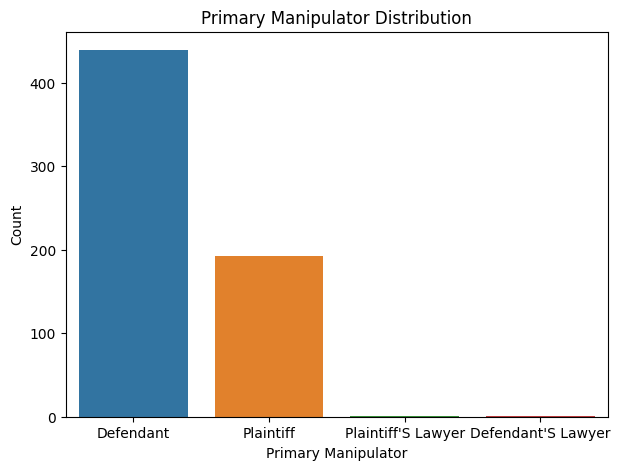

In [39]:
counts = df['Primary Manipulator'].value_counts()
percent = (counts / len(df) * 100).round(2)

print("Primary Manipulator distribution:")
print(pd.DataFrame({"Count": counts, "Percent (%)": percent}))

plt.figure(figsize=(7, 5))
sns.barplot(x=counts.index, y=counts.values)
plt.title('Primary Manipulator Distribution')
plt.ylabel('Count')
plt.show()

In [40]:
# Remove lawyer roles
mask = ~df['Primary Manipulator'].str.lower().str.contains('lawyer', na=False)

before = len(df)
df = df[mask]
removed = before - len(df)

print(f"Removed {removed} lawyer entries → {len(df)} rows remaining\n")

counts = df['Primary Manipulator'].value_counts()
percent = (counts / counts.sum() * 100).round(2)
print(pd.DataFrame({"Count": counts, "Percent (%)": percent}))

Removed 2 lawyer entries → 1033 rows remaining

                     Count  Percent (%)
Primary Manipulator                    
Defendant              439        69.57
Plaintiff              192        30.43


### 4.2 Manipulation Techniques Normalization 


In [41]:
col = df['Manipulation Techniques']
print(f"Unique values: {col.nunique()}")
print("Sample values (first 20):")
print(col.unique()[:20])


Unique values: 483
Sample values (first 20):
[' gaslighting, deflection' 'Minimization, Deflection' nan
 'minimization,Deflection, dismissal' 'minimization deflection persuasion'
 'deflection, minimization, persuasion' 'Minimization, deflection'
 'character attack, playing the victim, gaslighting, dismissal, deflection'
 'Minimization, Evasion' 'Minimization,Deflection ,Emotional Framing'
 'evasion, persuasion' 'Deflection, Guilt Tripping'
 ' Gaslighting,Minimization,Deflection' 'minimization, gaslighting'
 'playing the victim' 'minimization, deflection, persuasion'
 'emotional appeal, deflection'
 'Deflection , Minimization, Emotional Appeal, Gaslighting' ', deflection'
 'deflection, dismissal, minimization, exaggeration, emotional appeal']


In [42]:
canonical_techniques_ordered = {
    "gaslighting": 1, "guilt tripping": 2, "persuasion": 3, "evasion": 4,
    "framing the narrative": 5, "dismissal": 6, "character attack": 7,
    "deflection": 8, "minimization": 9, "emotional appeal": 10,
    "playing the victim": 11
}

normalization_map = {
    "playing the victim role": "playing the victim",
    "victim playing": "playing the victim",
    "plaing the victim": "playing the victim",
    "guilt-tripping": "guilt tripping",
    "guilttripping": "guilt tripping",
    "guilt - tripping": "guilt tripping",
    "emotional appealing": "emotional appeal",
    "emtional appeal": "emotional appeal",
    "emotion appeal": "emotional appeal",
    "appeal to emotion": "emotional appeal",
    "emotional blackmailing": "emotional appeal",
    "framing narrative": "framing the narrative",
    "gasligting": "gaslighting",
    "defelction": "deflection",
}

print(f"Canonical techniques: {len(canonical_techniques_ordered)}")
print(f"Normalization rules: {len(normalization_map)}")

Canonical techniques: 11
Normalization rules: 14


In [43]:
allowed_techniques_set = set(canonical_techniques_ordered.keys())
multi_word_techniques = sorted([t for t in allowed_techniques_set if ' ' in t], key=len, reverse=True)
single_word_techniques = sorted([t for t in allowed_techniques_set if ' ' not in t], key=len, reverse=True)

print(f"Multi-word techniques ({len(multi_word_techniques)}):")
for tech in multi_word_techniques:
    print(f"  - {tech}")
print(f"\nSingle-word techniques ({len(single_word_techniques)}):")
for tech in single_word_techniques:
    print(f"  - {tech}")

Multi-word techniques (5):
  - framing the narrative
  - playing the victim
  - character attack
  - emotional appeal
  - guilt tripping

Single-word techniques (6):
  - minimization
  - gaslighting
  - persuasion
  - deflection
  - dismissal
  - evasion


In [44]:
allowed_techniques_set = set(canonical_techniques_ordered.keys())
multi_word_techniques = sorted(
    [t for t in allowed_techniques_set if ' ' in t], key=len, reverse=True
)
single_word_techniques = sorted(
    [t for t in allowed_techniques_set if ' ' not in t], key=len, reverse=True
)

def clean_manipulation_techniques(text):
    if pd.isna(text):
        return np.nan

    text = re.sub(r'[.,;]+$', '', re.sub(r'\s+', ' ', str(text).lower()).strip())
    if not text:
        return np.nan

    temp = text
    for v, c in normalization_map.items():
        if ' ' in c:
            temp = re.sub(rf'\b{re.escape(v)}\b', c, temp)

    found, spans = set(), []

    for tech in multi_word_techniques:
        for m in re.finditer(rf'\b{re.escape(tech)}\b', temp):
            s, e = m.span()
            if not any(max(s, ps) < min(e, pe) for ps, pe in spans):
                found.add(tech)
                spans.append((s, e))

    spans.sort()
    remaining = []
    last = 0
    for s, e in spans:
        remaining.append(temp[last:s])
        last = e
    remaining.append(temp[last:])
    remaining = ' '.join(remaining)

    for w in re.split(r'\s*[,&/]\s*|\s+', remaining):
        w = w.strip('.,;')
        if not w:
            continue
        w = normalization_map.get(w, w)
        if w in single_word_techniques:
            found.add(w)

    if not found:
        return np.nan

    return ', '.join(sorted(found, key=lambda t: canonical_techniques_ordered[t]))

In [45]:
print("Cleaning 'Manipulation Techniques' column...")
print(f"Original unique values: {df['Manipulation Techniques'].nunique()}")

df['Original_Techniques'] = df['Manipulation Techniques']
df['Manipulation Techniques'] = df['Manipulation Techniques'].apply(
    clean_manipulation_techniques
)

print(f"After cleaning unique values: {df['Manipulation Techniques'].nunique()}")

Cleaning 'Manipulation Techniques' column...
Original unique values: 483
After cleaning unique values: 161


In [46]:
# Validation
changed = df[df['Original_Techniques'] != df['Manipulation Techniques']]
print("Sample Before vs After Cleaning:")
for _, row in changed.head(10).iterrows():
    print(f"\nBefore: {row['Original_Techniques']}")
    print(f"After:  {row['Manipulation Techniques']}")

print("\nTechnique Distribution (cleaned):")
print(df['Manipulation Techniques'].value_counts().head(20))

Sample Before vs After Cleaning:

Before:  gaslighting, deflection
After:  gaslighting, deflection

Before: Minimization, Deflection
After:  deflection, minimization

Before: nan
After:  nan

Before: minimization,Deflection, dismissal
After:  dismissal, deflection, minimization

Before: minimization deflection persuasion
After:  persuasion, deflection, minimization

Before: nan
After:  nan

Before: deflection, minimization, persuasion
After:  persuasion, deflection, minimization

Before: Minimization, deflection
After:  deflection, minimization

Before: character attack, playing the victim, gaslighting, dismissal, deflection
After:  gaslighting, dismissal, character attack, deflection, playing the victim

Before: Minimization, Evasion
After:  evasion, minimization

Technique Distribution (cleaned):
Manipulation Techniques
deflection                                                       35
deflection, minimization                                         33
evasion, deflection           

### 4.3. Remove Inconsistent Samples 
Manipulative = 1 but missing manipulation techniques or primary manipulator


In [47]:

invalid_mask = (
    (df['Manipulative'] == 1) &
    (
        df['Manipulation Techniques'].isna() |
        df['Primary Manipulator'].isna()
    )
)

original_rows = len(df)
rows_deleted = invalid_mask.sum()

print(f"Invalid rows: {rows_deleted}")

df = df[~invalid_mask].copy()

print(
    f"Removed {rows_deleted} inconsistent rows "
    f"({rows_deleted/original_rows:.2%}) → {len(df)} rows remaining"
)

Invalid rows: 4
Removed 4 inconsistent rows (0.39%) → 1029 rows remaining


## 5. Dialogue Standardization
Normalize speaker roles (e.g., [Judge] → Judge:) \
Remove formatting artifacts (bold, brackets, noise) \
Enforce consistent Role: Content structure

In [48]:
ROLE = r'(Judge|Plaintiff|Defendant|Lawyer of Plaintiff|Lawyer of Defendant)'

def standardize_to_pure_roles(text):
    if not isinstance(text, str):
        return ""

    text = re.sub(rf'\[({ROLE}|Lawyer.*?)\]', r'\1:', text)
    text = text.replace("**", "").replace('\r\n', '\n').replace('\r', '\n')
    text = re.sub(rf'^{ROLE}(\s\(.*?\))?[:]?\s*\n?', r'\1: ', text, flags=re.MULTILINE)
    text = re.sub(r'\n\s*\n+', '\n', text)

    lines = []
    for l in map(str.strip, text.split('\n')):
        if not l:
            continue
        l = re.sub(rf'^{ROLE}(\s\(.*?\))?:', r'\1:', l)
        if ":" not in l[:50]:
            l = re.sub(rf'^{ROLE}\s+(.*)', r'\1: \2', l)
        l = re.sub(r'^([^:]+:\s*)"(.*)"$', r'\1\2', l)
        l = l.replace("(Laughter.)", "").replace("(Laughter)", "")
        l = re.sub(r'(\w+:)\s+', r'\1 ', l)
        lines.append(l)

    return "\n".join(lines)

df['Dialogue'] = df['Dialogue'].apply(standardize_to_pure_roles)
df.head(20)

,IDs,Dialogue,Manipulative,Primary Manipulator,Manipulation Techniques,Original_Techniques
0,804,Judge: Welcome back to The People's Court. Nex...,1,Plaintiff,"gaslighting, deflection","gaslighting, deflection"
1,154,Judge: you shouldn't have a problem paying the...,1,Defendant,"deflection, minimization","Minimization, Deflection"
2,566,Judge: But it says a notice to appear under Se...,0,NaN,NaN,NaN
3,594,"Judge: All parties, please raise your right ha...",1,Defendant,"dismissal, deflection, minimization","minimization,Deflection, dismissal"
4,116,"Judge: Okay, Elias Samas.\nPlaintiff: That's m...",1,Defendant,"persuasion, deflection, minimization",minimization deflection persuasion
5,780,Judge: -- but I just want to understand what's...,0,NaN,NaN,NaN
6,558,"Judge: All parties, please welcome back to the...",1,Plaintiff,"persuasion, deflection, minimization","deflection, minimization, persuasion"
7,762,"Judge: But you had told him, 'I'm pregnant eig...",1,Defendant,"deflection, minimization","Minimization, deflection"
8,656,"Judge: Tracy Unique Alexander. Yes, you are su...",1,Defendant,"gaslighting, dismissal, character attack, defl...","character attack, playing the victim, gaslight..."
9,956,Judge: So all of this money and he hasn't give...,1,Defendant,"evasion, minimization","Minimization, Evasion"


## 4. Statistical Analysis

In [49]:
df = df.drop(columns=['Original_Techniques', 'IDs'])

print("=== FINAL DATA ===")
print(f"\nDataset shape: {df.shape}")
print(f"\nMissing values:")
print(df.isnull().sum())
print(f"\nData types:")
print(df.dtypes)

=== FINAL DATA ===

Dataset shape: (1029, 4)

Missing values:
Dialogue                     0
Manipulative                 0
Primary Manipulator        401
Manipulation Techniques    401
dtype: int64

Data types:
Dialogue                   object
Manipulative                int64
Primary Manipulator        object
Manipulation Techniques    object
dtype: object


Word Count Statistics:
count    1029.000000
mean      880.485909
std       497.854948
min        35.000000
25%       654.000000
50%       930.000000
75%      1140.000000
max      2742.000000
Name: Dialogue, dtype: float64


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


Text(0, 0.5, 'Frequency')

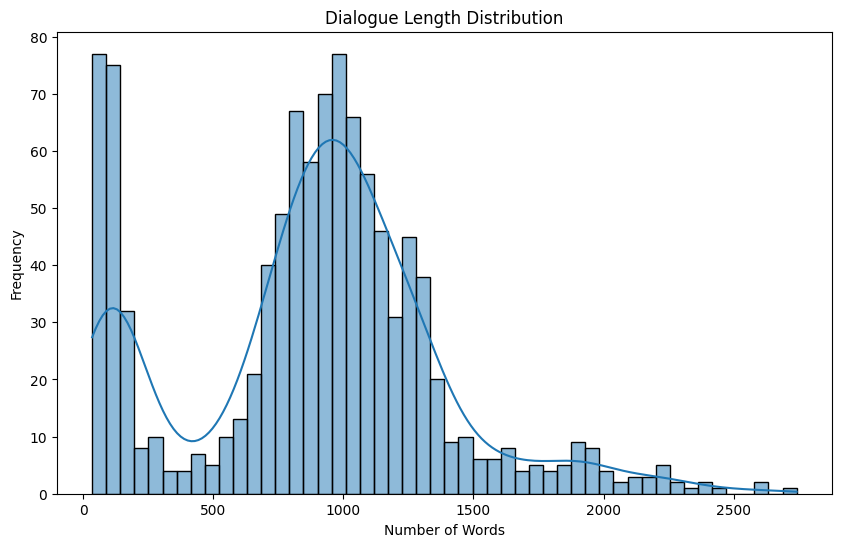

In [50]:
word_count = df['Dialogue'].astype(str).str.split().str.len()

print("Word Count Statistics:")
print(word_count.describe())

plt.figure(figsize=(10, 6))
sns.histplot(word_count, bins=50, kde=True)
plt.title('Dialogue Length Distribution')
plt.xlabel('Number of Words')
plt.ylabel('Frequency')

Manipulative distribution:
              Count  Percent (%)
Manipulative                    
1               628        61.03
0               401        38.97


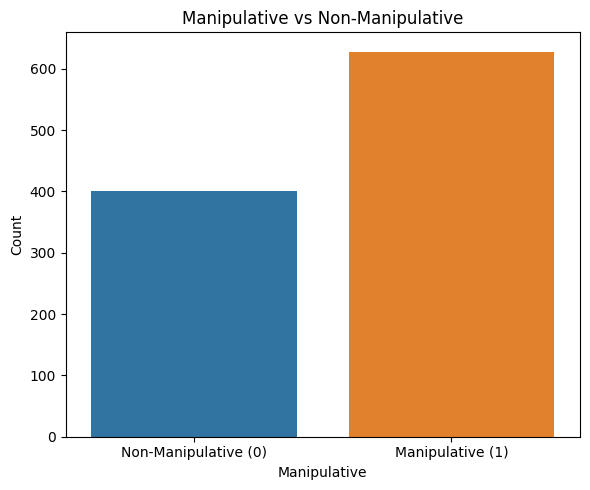

In [52]:
# --- 4.1 Manipulative Label Distribution ---

manip_counts = df['Manipulative'].value_counts()
manip_pct = df['Manipulative'].value_counts(normalize=True) * 100

print("Manipulative distribution:")
print(pd.DataFrame({"Count": manip_counts, "Percent (%)": manip_pct.round(2)}))

plt.figure(figsize=(6, 5))
sns.barplot(x=manip_counts.index, y=manip_counts.values)
plt.title('Manipulative vs Non-Manipulative')
plt.xticks([0, 1], ['Non-Manipulative (0)', 'Manipulative (1)'])
plt.ylabel('Count')
plt.tight_layout()
plt.show()

Primary Manipulator distribution:
                     Count  Percent (%)
Primary Manipulator                    
Defendant              437        69.59
Plaintiff              191        30.41


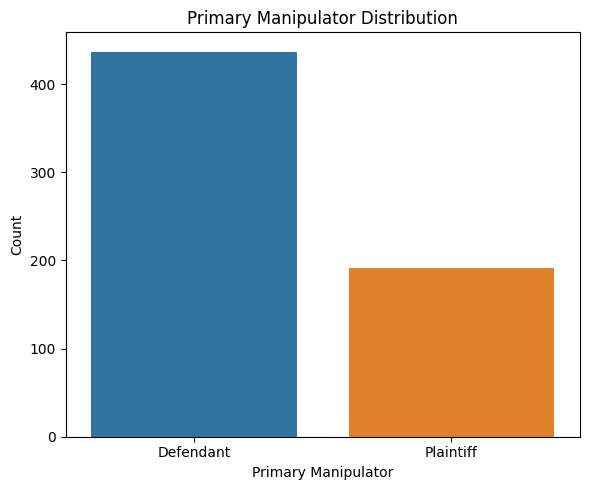

In [53]:
# --- 4.2 Primary Manipulator Distribution ---

counts = df['Primary Manipulator'].value_counts()
percent = (counts / counts.sum() * 100).round(2)

print("Primary Manipulator distribution:")
print(pd.DataFrame({"Count": counts, "Percent (%)": percent}))

plt.figure(figsize=(6, 5))
sns.barplot(x=counts.index, y=counts.values)
plt.title('Primary Manipulator Distribution')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

In [54]:
# --- 4.3 Individual Technique Frequency ---

all_tech = (
    df['Manipulation Techniques']
    .dropna()
    .astype(str)
    .str.split(',')
    .explode()
    .str.strip()
)

total_samples = df['Manipulation Techniques'].notna().sum()
tech_counts = all_tech.value_counts()

# Tạo tech_df để dùng cho biểu đồ
tech_df = pd.DataFrame({"Count": tech_counts})

print(f"Samples with techniques: {total_samples}")
print(f"Avg techniques/sample: {len(all_tech)/total_samples:.2f}\n")

print("Individual Technique Frequency:")
for t, c in tech_counts.items():
    print(f"  {t}: {c} ({c/total_samples*100:.2f}%)")

Samples with techniques: 628
Avg techniques/sample: 2.50

Individual Technique Frequency:
  deflection: 385 (61.31%)
  minimization: 213 (33.92%)
  gaslighting: 199 (31.69%)
  evasion: 193 (30.73%)
  playing the victim: 181 (28.82%)
  emotional appeal: 150 (23.89%)
  persuasion: 108 (17.20%)
  framing the narrative: 52 (8.28%)
  guilt tripping: 37 (5.89%)
  dismissal: 34 (5.41%)
  character attack: 17 (2.71%)


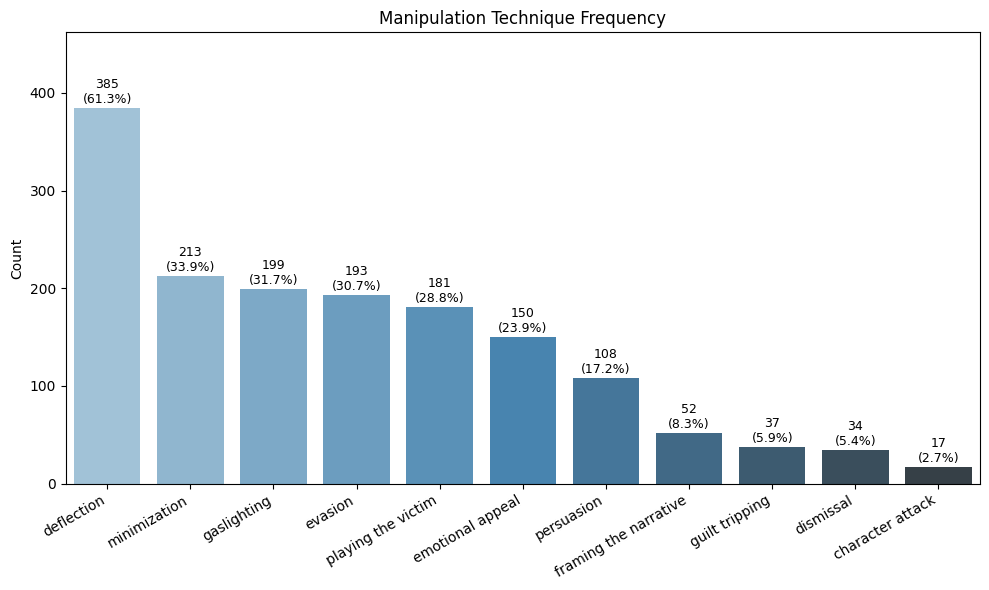

In [55]:
# Vẽ biểu đồ tần suất kỹ thuật
fig, ax = plt.subplots(figsize=(10, 6))

sns.barplot(x=tech_df.index, y=tech_df["Count"], palette="Blues_d", ax=ax)

for bar, val in zip(ax.patches, tech_df["Count"]):
    pct = val / total_samples * 100
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 2,
        f"{val}\n({pct:.1f}%)",
        ha='center', va='bottom', fontsize=9
    )

ax.set_ylabel("Count")
ax.set_xlabel("")
ax.set_title("Manipulation Technique Frequency")
ax.set_ylim(0, tech_df["Count"].max() * 1.2)
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig("technique_frequency.png", dpi=150, bbox_inches='tight')
plt.show()

In [56]:
# --- 4.4 Top Technique Combinations ---

print("Top 20 Technique Combinations:")
combo = df['Manipulation Techniques'].value_counts()
for k, v in combo.head(20).items():
    print(f"  {k}: {v}")

Top 20 Technique Combinations:
  deflection: 35
  deflection, minimization: 33
  evasion, deflection: 26
  gaslighting, evasion, deflection: 18
  emotional appeal: 17
  minimization: 16
  gaslighting, deflection, playing the victim: 16
  gaslighting: 16
  gaslighting, evasion, deflection, playing the victim: 15
  persuasion, deflection, minimization: 15
  gaslighting, deflection: 14
  evasion, deflection, minimization: 14
  playing the victim: 13
  evasion, deflection, playing the victim: 13
  deflection, emotional appeal: 12
  gaslighting, deflection, minimization: 11
  deflection, playing the victim: 10
  persuasion, emotional appeal: 10
  gaslighting, deflection, minimization, playing the victim: 8
  gaslighting, deflection, emotional appeal, playing the victim: 8


In [57]:
# --- 4.5 Class Imbalance ---

major, minor = manip_counts.max(), manip_counts.min()
print(f"Class imbalance ratio: {major/minor:.2f}:1")

Class imbalance ratio: 1.57:1


## 5. Data Splitting

### Stratified Train-Validation-Test Split

Split the cleaned dataset into training (70%), validation (15%), and test (15%) sets using stratified sampling to maintain class distribution across all splits. This ensures reliable model evaluation and prevents data leakage.

In [58]:
TRAIN_SIZE, VAL_SIZE, TEST_SIZE = 0.7, 0.15, 0.15
RANDOM_STATE = 42

# Train vs Temp
df_train, df_temp = train_test_split(
    df,
    test_size=1 - TRAIN_SIZE,
    random_state=RANDOM_STATE,
    stratify=df['Manipulative']
)

# Val vs Test
val_ratio = TEST_SIZE / (VAL_SIZE + TEST_SIZE)

df_val, df_test = train_test_split(
    df_temp,
    test_size=val_ratio,
    random_state=RANDOM_STATE,
    stratify=df_temp['Manipulative']
)

# ===== SUMMARY =====
print("=== DATASET SPLIT SUMMARY ===")
print(f"Total: {len(df)}")
print(f"Train: {len(df_train)} ({len(df_train)/len(df):.1%})")
print(f"Val:   {len(df_val)} ({len(df_val)/len(df):.1%})")
print(f"Test:  {len(df_test)} ({len(df_test)/len(df):.1%})")

# ===== DISTRIBUTION =====
def show_dist(name, data):
    print(f"\n{name}")
    print(data['Manipulative'].value_counts(normalize=True).mul(100).round(2))

print("\n=== CLASS DISTRIBUTION ===")
show_dist("Original", df)
show_dist("Train", df_train)
show_dist("Validation", df_val)
show_dist("Test", df_test)

# ===== SAVE =====
df_train.to_csv("train_split.csv", index=False)
df_val.to_csv("val_split.csv", index=False)
df_test.to_csv("test_split.csv", index=False)

print("\nFiles saved successfully!")

=== DATASET SPLIT SUMMARY ===
Total: 1029
Train: 720 (70.0%)
Val:   154 (15.0%)
Test:  155 (15.1%)

=== CLASS DISTRIBUTION ===

Original
Manipulative
1    61.03
0    38.97
Name: proportion, dtype: float64

Train
Manipulative
1    60.97
0    39.03
Name: proportion, dtype: float64

Validation
Manipulative
1    61.04
0    38.96
Name: proportion, dtype: float64

Test
Manipulative
1    61.29
0    38.71
Name: proportion, dtype: float64

Files saved successfully!
